In [15]:
import anndata as ad
import pandas as pd
import numpy as np
import random
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import NearestNeighbors
import igraph as ig
import leidenalg
from wompwomp import plot_alluvial
from statsmodels.stats.multitest import multipletests
from upsetplot import UpSet, from_memberships
from itertools import chain
plt.style.use('default')  

In [2]:
# replace this path with the path for where the downloaded supplement file is located
supplement_file_path = "/home/nikki/Supplementary_data/"

# replace this path with output path
output_path = "/home/nikki/swarna2025_figs/figs/fig4/"

# Fig1

## a

In [3]:
partition_list = [
    'Sex', 
    'Age', 
    'Ancestry', 
    'Celltype',
    # Two-way interactions
    'Sex:Age',
    'Sex:Celltype',
    'Sex:Ancestry',
    'Age:Celltype',
    'Age:Ancestry',
    'Celltype:Ancestry',
    # Three-way interactions
    'Sex:Age:Celltype',
    'Sex:Age:Ancestry',
    'Sex:Celltype:Ancestry',
    'Age:Celltype:Ancestry',
    # Four-way interaction
    'Sex:Age:Celltype:Ancestry'
]

/home/nikki/miniconda3/envs/figs_env/lib/python3.11/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/nikki/miniconda3/envs/figs_env/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles[

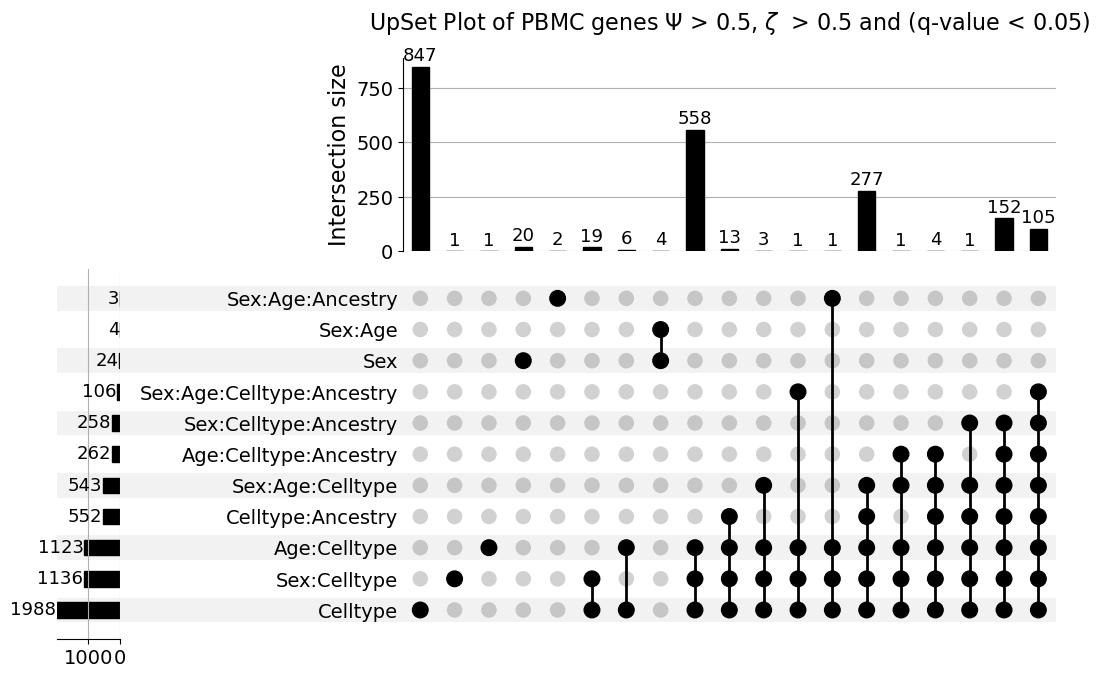

In [11]:
fdr_thresh = 0.05
psi_thresh = 0.5
zeta_thresh = 0.5

# Read all DataFrames and label them by partition
dfs = []
for partition in partition_list:
    pvals_path = os.path.join(supplement_file_path, f"Human_PBMC/{partition}.csv")
    df = pd.read_csv(pvals_path)
    df['partition'] = partition
    dfs.append(df)

# Combine all data for global FDR correction
combined_df = pd.concat(dfs, ignore_index=True)

# Global FDR correction for both Psi and Zeta
combined_df['Psi p-value'] = combined_df['Psi p-value'].astype(float)
combined_df['Zeta p-value'] = combined_df['Zeta p-value'].astype(float)

_, combined_df['Psi FDR'], _, _ = multipletests(combined_df['Psi p-value'], method='fdr_bh')
_, combined_df['Zeta FDR'], _, _ = multipletests(combined_df['Zeta p-value'], method='fdr_bh')

# Filter for genes significant in both Psi and Zeta, and with effect sizes > 0.5
significant = combined_df[
    (combined_df['Psi FDR'] <= fdr_thresh) &
    (combined_df['Zeta FDR'] <= fdr_thresh) &
    (combined_df['Psi'] > psi_thresh) &
    (combined_df['Zeta'] > zeta_thresh)
]

# Create sets of significant genes per partition, ensuring no duplicates
partition_gene_sets = {
    partition: set(
        significant[significant['partition'] == partition]['gene_name'].drop_duplicates()
    )
    for partition in partition_list
}

all_genes = set(chain.from_iterable(partition_gene_sets.values()))
memberships = []

for gene in all_genes:
    gene_membership = [
        partition for partition, gene_set in partition_gene_sets.items() if gene in gene_set
    ]
    memberships.append(gene_membership)
    
# Create UpSet data and plot
# Set larger font sizes globally
plt.rcParams.update({
    'font.size': 13,          # base font size
    'axes.titlesize': 16,     # title size
    'axes.labelsize': 16,     # axis label size
    'xtick.labelsize': 14,    # x-axis tick labels
    'ytick.labelsize': 14,    # y-axis tick labels
    'legend.fontsize': 14     # legend (if any)
})

upset_data = from_memberships(memberships)

# Create the UpSet plot
UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='degree',
).plot()

# Title and layout
plt.title(
    fr'UpSet Plot of PBMC genes $\Psi$ > {psi_thresh}, $\zeta$  > {zeta_thresh} and (q-value < {fdr_thresh})',
    pad=20
)
plt.tight_layout()
out_fig_path = os.path.join(output_path, "upset_human_pbmc.png")
plt.savefig(out_fig_path)
plt.show()



## b

In [74]:
df_path = os.path.join(supplement_file_path, "Human_PBMC/psi_block_Celltype.csv")
df = pd.read_csv(df_path, index_col = 0)
df = df.drop(["ensembl_id"], axis = 1)
clusters = sorted(df.columns)
df = df.loc[df.index.intersection(unique_to_intersection)]


SEED = 45
np.random.seed(SEED)
random.seed(SEED)
# X = numpy array from the contribution score DataFrame
X = df.values  # shape (n_genes, 17)

# Build kNN graph — 10 neighbors usually works well
k = 10
nn = NearestNeighbors(n_neighbors=k, metric='cosine')
nn.fit(X)
distances, indices = nn.kneighbors(X)

# Construct edges: undirected graph
edges = []
for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            edges.append((i, j))

# Build iGraph object
g = ig.Graph(edges=edges, directed=False)

# Run Leiden clustering
partition = leidenalg.find_partition(
    g, 
    leidenalg.RBConfigurationVertexPartition,
    seed=SEED  # Add this
)


# Get cluster labels
labels = np.array(partition.membership)
df['cluster'] = labels

cluster_profiles = df.groupby('cluster').mean().drop(columns='cluster', errors='ignore')

num_active_celltype = cluster_profiles.apply(lambda row: (row > 0.01).sum(), axis=1)
super_specific = cluster_profiles.apply(lambda row: (row > 0.20).sum(), axis=1)
cluster_profiles['num_active_celltypes'] = num_active_celltype
cluster_profiles['super_specific'] = super_specific
cluster_profiles['specificity_label'] = cluster_profiles['num_active_celltypes'].map(
    lambda x: f"specific to {x} cell types"
)


# Prepare heatmap data and sort columns alphabetically
heatmap_data = cluster_profiles.drop(columns=['num_active_celltypes', 'super_specific', 'specificity_label'])
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]  

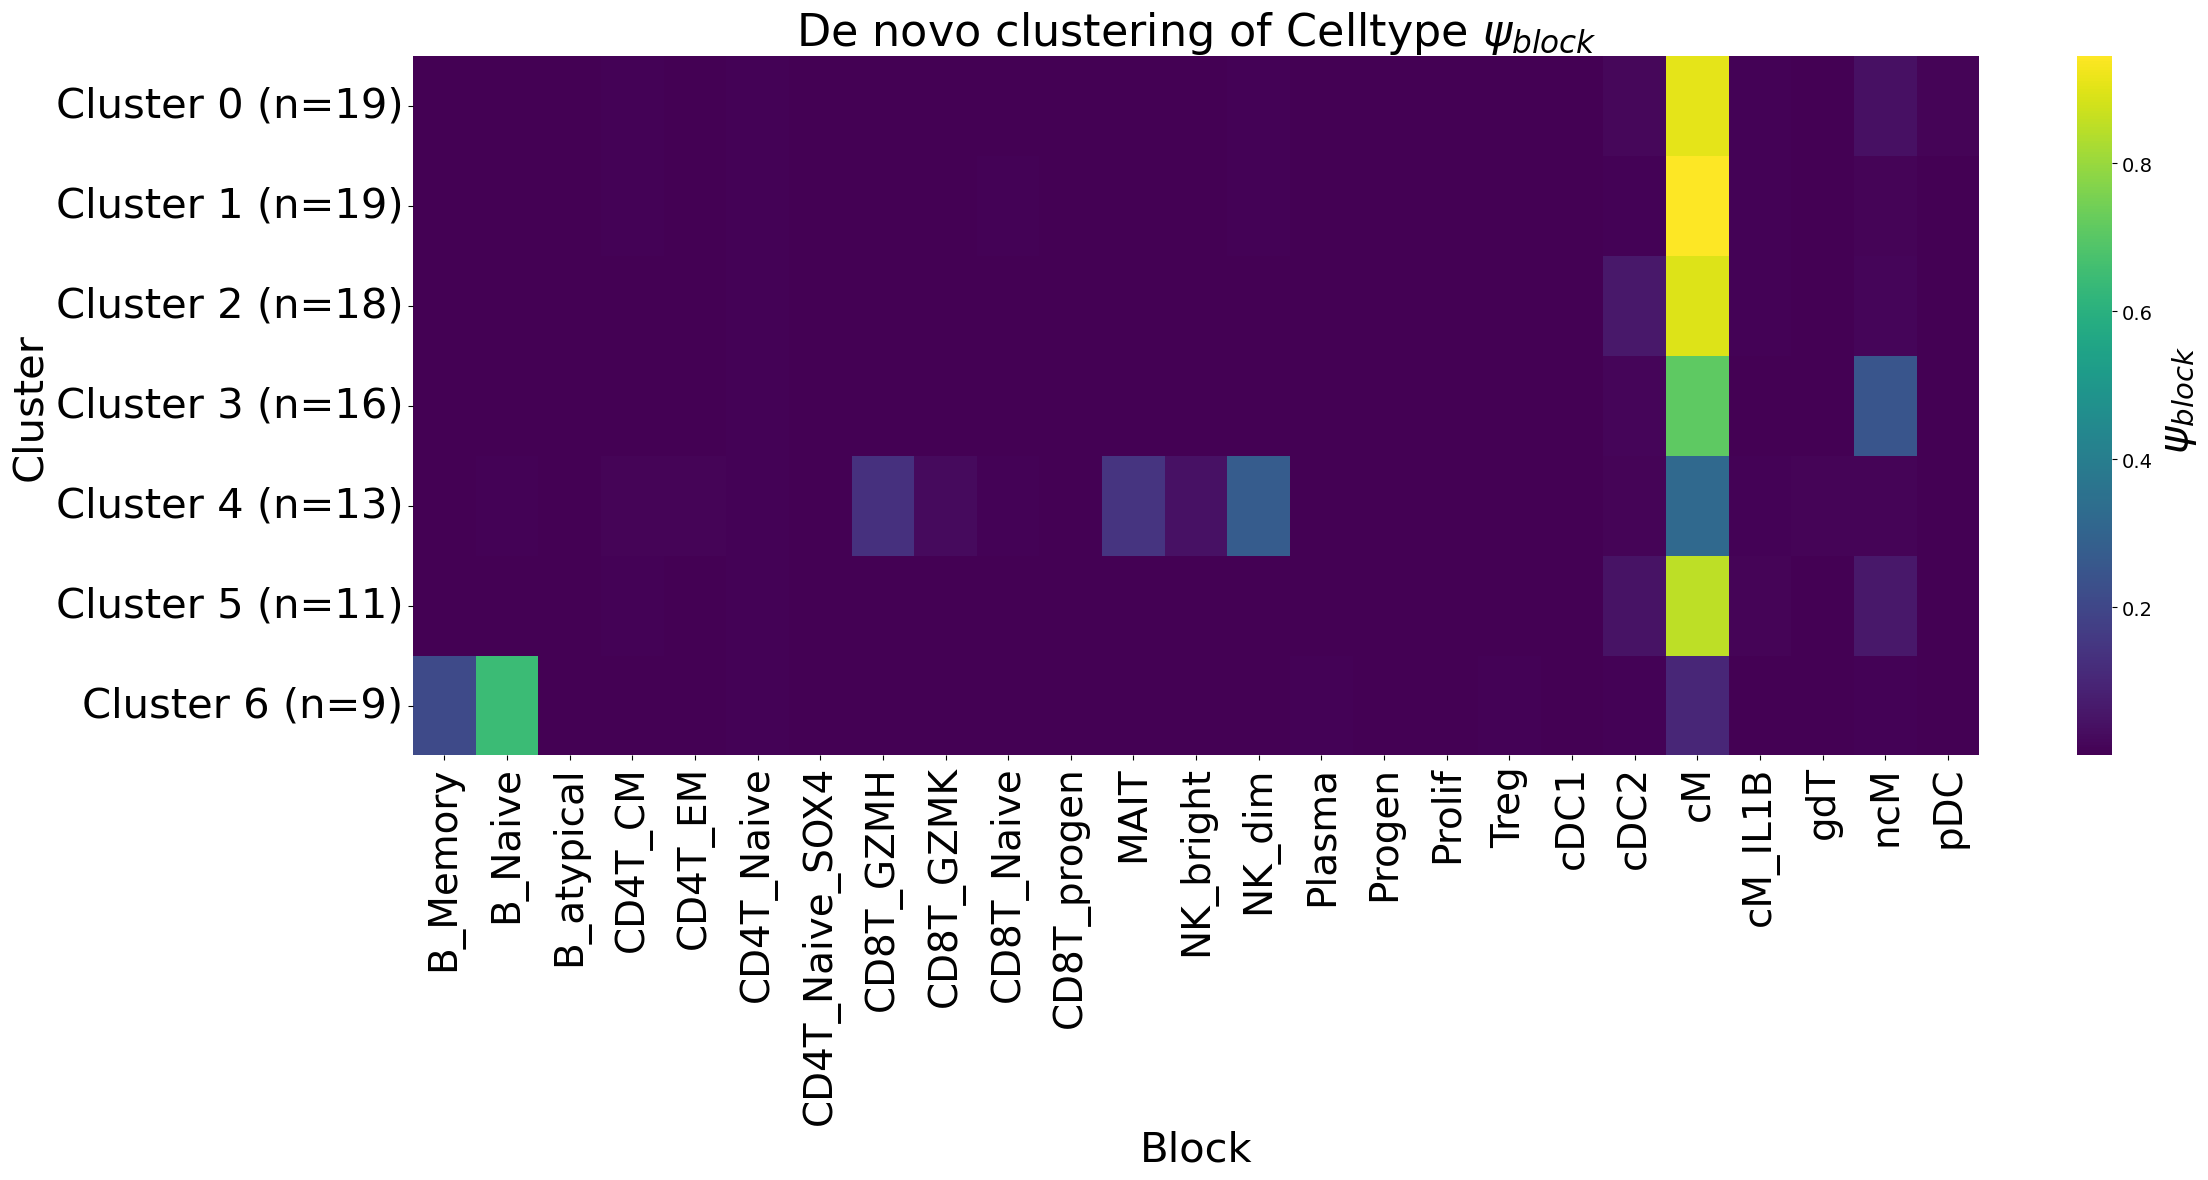

In [77]:
fontsize = 30
plt.figure(figsize=(24, 12))

# Count how many genes are in each cluster
gene_counts = df['cluster'].value_counts().sort_index()
y_labels = [f"Cluster {i} (n={gene_counts[i]})" for i in heatmap_data.index]

# Create heatmap with custom y-tick labels
ax = sns.heatmap(heatmap_data, cmap='viridis', xticklabels=True, yticklabels=y_labels)

# Add colorbar label
colorbar = ax.collections[0].colorbar
colorbar.set_label(' $\psi_{{block}}$', fontsize=fontsize)

plt.title(f"De novo clustering of Celltype $\psi_{{block}}$", fontsize=fontsize+2)
plt.xlabel("Block", fontsize=fontsize)
plt.ylabel("Cluster", fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize, rotation=0)
plt.tight_layout()
fig_out_path = os.path.join(output_path, f"105_variable_genes_clustering_by_celltype.png")
plt.savefig(fig_out_path)
plt.show()


## c, d and f

Sorting Data with sorting algorithm = neighbornet
Sorting Distance matrix with algorithm neighbornet
Determining Optimal Cycle Start
neighbornet_objective for iteration 0 = 1.5577498737712862e+16
neighbornet_objective for iteration 1 = 1.453496245490076e+16
neighbornet_objective for iteration 2 = 1.4530554275094388e+16
neighbornet_objective for iteration 3 = 1.4527329022642264e+16
neighbornet_objective for iteration 4 = 1.4536651994976848e+16
neighbornet_objective for iteration 5 = 1.985879682099535e+16
neighbornet_objective for iteration 6 = 1.984518837896102e+16
neighbornet_objective for iteration 7 = 1.987734327012131e+16
neighbornet_objective for iteration 8 = 1.7838610516631344e+16
neighbornet_objective for iteration 9 = 1.769828779711193e+16
neighbornet_objective for iteration 10 = 1.6075952298540648e+16
neighbornet_objective for iteration 11 = 1.6068493157415218e+16
neighbornet_objective for iteration 12 = 1.6072579962286668e+16
neighbornet_objective for iteration 13 = 1.6070034

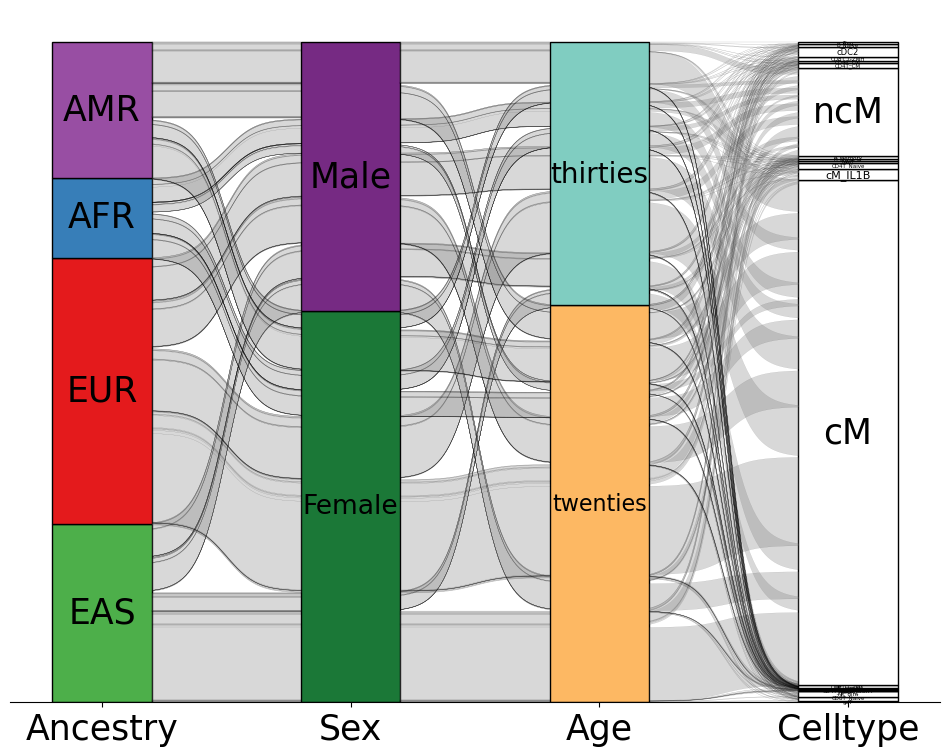

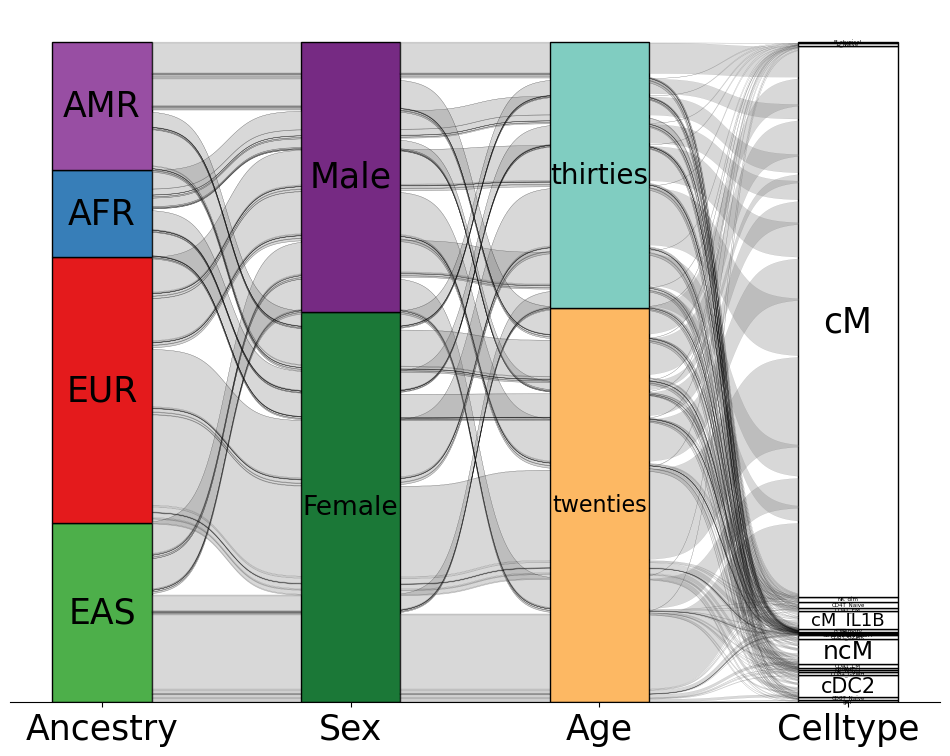

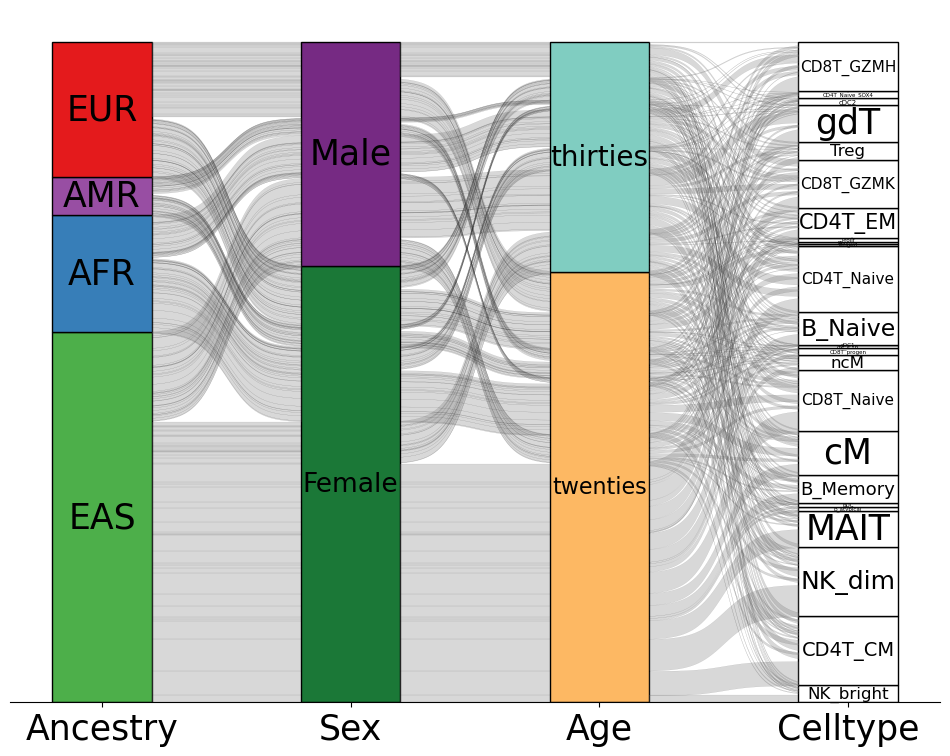

In [79]:
genes = ["SLC11A1", "TREM1", "RNF17"]
for gene_name in genes:
    df_path = os.path.join(supplement_file_path, f"Human_PBMC/{gene_name}_pseudobulk_wompwomp.csv")
    df = pd.read_csv(df_path)

    # cleaning out empty levels to improve effeciency
    df = df[df['umi_total'] > 0]
    df = df[['Sex', 'binned_age', 'L3_manual', 'Assignment', 'umi_total']]
    df = df.rename(columns={
        'binned_age': 'Age',
        'L3_manual': 'Celltype',
        'Assignment': 'Ancestry'
    })
    df = df.groupby(['Sex', 'Age', 'Celltype', 'Ancestry']).agg('sum').reset_index()

    color_dict = {
        "twenties": "#FDB863",   # light orange / amber
        "thirties": "#80CDC1", # light teal / aqua
        "EUR": "#E41A1C",   # red
        "AFR": "#377EB8",   # blue
        "EAS": "#4DAF4A",   # green
        "AMR": "#984EA3" ,   # purple
        "Male": "#762A83",   # violet
        "Female": "#1B7837"  # dark green
    }



    fig, order_dict = plot_alluvial(df, #pandas data frame  
                      # general function arguments
                      graphing_columns = ['Ancestry','Sex', 'Age', 'Celltype'], column_weights = 'umi_total',
                                    color_alluvium = False, match_colors = False, verbose = True,optimize_column_order = False,
                                    sorting_algorithm = 'neighbornet', return_order_dict = True, color_dict = color_dict,
                                    fill_missing_colors = "#FFFFFF",
                                    save_height=12, save_width=9, default_text_size=25, alluvial_alpha=0.3,resolution=30)
    fig_out_path = os.path.join(output_path, f"{gene_name}_alluvial.png")
    fig[0].savefig(fig_out_path)

## e

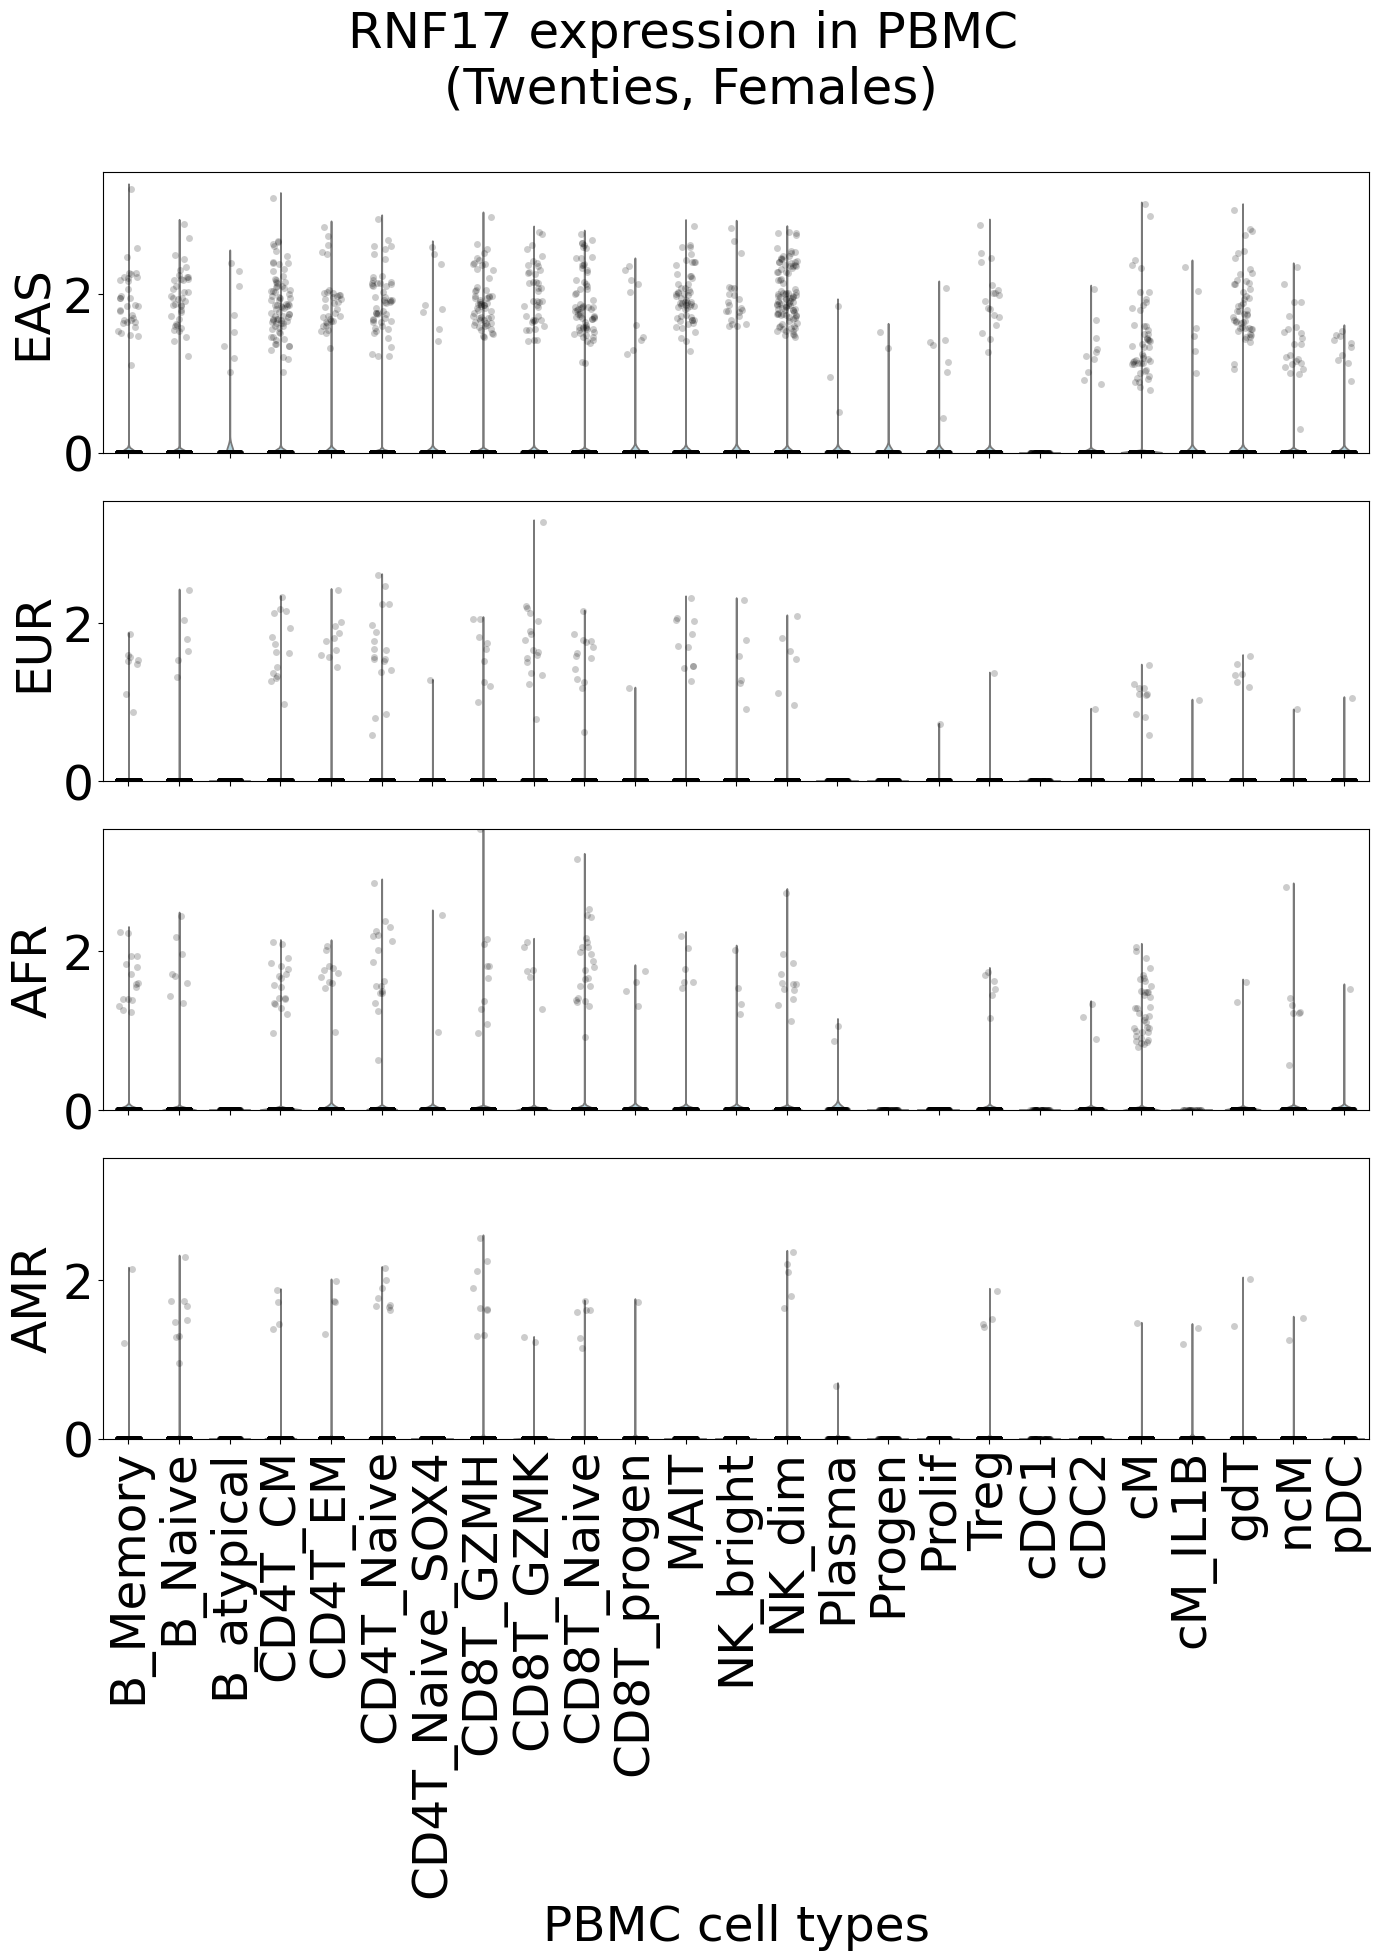

In [99]:
gene_adata_path = os.path.join(supplement_file_path, f"Human_PBMC/Rnf17_twenties_females.h5ad")
gene_adata = ad.read_h5ad(gene_adata_path)

fontsize = 35
expr = gene_adata.X
expr = expr.toarray().flatten() if hasattr(expr, "toarray") else expr.flatten()

df_gene = pd.DataFrame({
    "expression": expr,
    "celltype": gene_adata.obs["L3_manual"].values,
    "Ancestry": gene_adata.obs["Ancestry"].values,
    "Gene": gene
})

# --- Global y-limit for consistency across strains ---
ymax = df_gene["expression"].max()

# --- Make one subplot per strain ---
strains = df_gene["Ancestry"].unique()
fig, axes = plt.subplots(len(strains), 1, figsize=(14, 5*len(strains)), sharey=True, sharex=True)
fig.suptitle(f"{gene} expression in PBMC \n(Twenties, Females)", fontsize=fontsize+1)

if len(strains) == 1:
    axes = [axes]

for ax, strain in zip(axes, strains):
    df_strain = df_gene[df_gene["Ancestry"] == strain]

    sns.violinplot(
        data=df_strain,
        x="celltype", y="expression",
        color="lightblue",  # same color per gene, can customize
        inner=None,
        ax=ax
    )
    sns.stripplot(
        data=df_strain,
        x="celltype", y="expression",
        color="black", jitter=0.2, alpha=0.2,
        ax=ax
    )

    ax.set_ylabel(f"{strain}", fontsize=fontsize)
    ax.set_xlabel("PBMC cell types", fontsize=fontsize)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="x", rotation=90, labelsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave space for suptitle
fig_out_path = os.path.join(output_path, "Rnf17_violin.png")
fig.savefig(fig_out_path, bbox_inches="tight")
plt.show()